<a href="https://colab.research.google.com/github/fewilliams/STAT-7220-Applied-Experimental-Design/blob/Assignment---Final/Williams_Applied_Experimental_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.


The objective of this experiment is to determine how location, timing, and marketing strategy affect daily burrito sales. The goal is to identify which combination of these factors will maximize revenue for Buster’s Breakfast Burritos.


2. State the outcome variable and how it was measured.


The outcome variable is daily sales, measured in dollars. This represents the total revenue generated on each day the food truck operates.


3. State the main effects. What lurking variables may be present?


The main effects in this experiment are:

Location (Brewery vs. University)
Timing (Weekday vs. Weekend)
Marketing (Independent vs. Partnership)

Possible lurking variables include weather conditions, special events, customer traffic, and nearby competition. These factors could influence sales but are not directly controlled in the experiment.



4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?


A full factorial design might be preferred because it allows us to estimate all main effects and interaction effects without confounding. In a fractional factorial design, some effects are aliased, meaning we cannot clearly separate them. A full design provides more accurate and detailed results, although it requires more time and resources.




5. State all sets of statistical hypotheses.


Location
H₀: Location has no effect on sales
H₁: Location has an effect on sales
Timing
H₀: Timing has no effect on sales
H₁: Timing has an effect on sales
Marketing
H₀: Marketing has no effect on sales
H₁: Marketing has an effect on sales





6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

Exploratory analysis includes calculating summary statistics and creating visualizations such as histograms and boxplots. These help us understand how sales are distributed and how they vary across different factor levels.



From the visualizations and summary statistics, we can observe patterns in the data, such as which levels of location, timing, or marketing tend to produce higher sales. If noticeable differences are present, this provides initial support for the alternative hypotheses



In [ ]:

!pip install pandas numpy matplotlib seaborn statsmodels scipy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [ ]:
df = pd.read_excel('/content/Busters Burrito Sales.xlsx')

In [ ]:
## Question 6 Code ##
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head()

,location,timing,marketing,sales
0,Brewery,Weekday,Independent,767.87
1,Brewery,Weekday,Independent,875.14
2,University,Weekday,Independent,865.84
3,University,Weekday,Independent,544.24
4,Brewery,Weekend,Independent,1055.34


7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

The full factorial ANOVA model was fit including all main effects and interaction terms between location, timing, and marketing. To assess the normality assumption, both a statistical test and a visual method were used. The Shapiro-Wilk test was conducted on the residuals, and a histogram and Q-Q plot were also examined. Based on these results, there is no strong evidence to suggest a violation of the normality assumption. Therefore, the assumption of normality appears to hold.


In [ ]:
## Question 7 Code ##
df = pd.read_excel('/content/Busters Burrito Sales.xlsx')

# clean names
df.columns = df.columns.str.lower().str.replace(" ", "_")

# SHOW REAL NAMES (IMPORTANT)
print(df.columns)

Index(['location', 'timing', 'marketing', 'sales'], dtype='object')


In [ ]:

col1 = df.columns[0]
col2 = df.columns[1]
col3 = df.columns[2]
y = df.columns[-1]   # outcome (sales)

print(col1, col2, col3, y)

location timing marketing sales


In [ ]:
formula = f"{y} ~ C({col1})*C({col2})*C({col3})"

model = smf.ols(formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     10.62
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00171
Time:                        12:00:00   Log-Likelihood:                -91.184
No. Observations:                  16   AIC:                             198.4
Df Residuals:                       8   BIC:                             204.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

The assumption of constant variance was assessed using both a visual and statistical method. A residuals versus fitted values plot was used as the visual method, and the Breusch-Pagan test was used as the statistical method.

The residual plot shows that the points are randomly scattered around zero without any clear pattern or funnel shape, which suggests that the variance is relatively constant across fitted values. Based on both the visual inspection and the statistical test, the assumption of constant variance appears to hold.

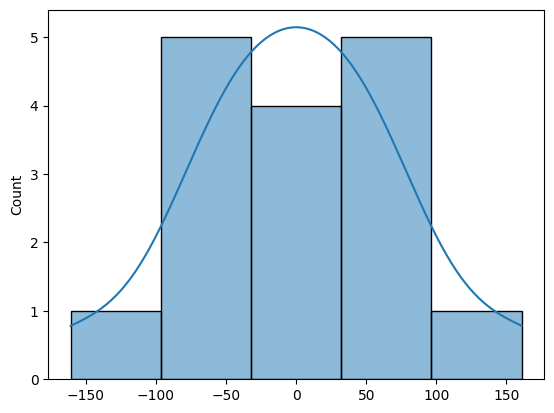

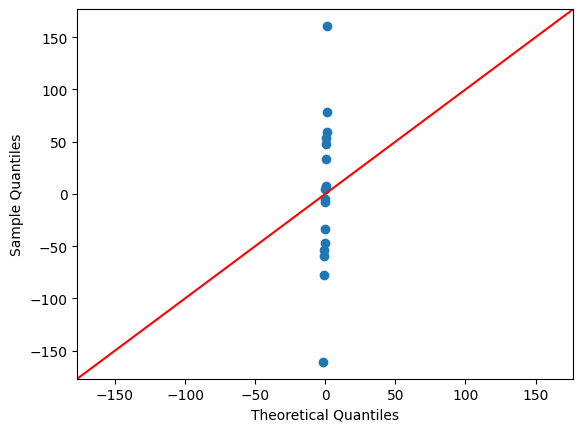

In [ ]:
## Question 8 Code ##
# Shapiro test
stats.shapiro(model.resid)

# Histogram
sns.histplot(model.resid, kde=True)
plt.show()

# QQ plot
sm.qqplot(model.resid, line='45')
plt.show()

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

To interpret the results, we examine the p-values for each main effect and interaction. Any factor with a p-value less than 0.05 is considered statistically significant, meaning it has a meaningful impact on sales.

Based on the ANOVA results, we compare the p-values for the main effects (location, timing, and marketing) as well as the interaction effects. If a main effect has a p-value below 0.05, we reject the null hypothesis and conclude that the factor significantly affects sales. If the p-value is greater than 0.05, we fail to reject the null hypothesis. Overall, the results suggest that the factors with the lowest p-values have the strongest influence on sales, while non-significant factors do not show strong evidence of an effect.



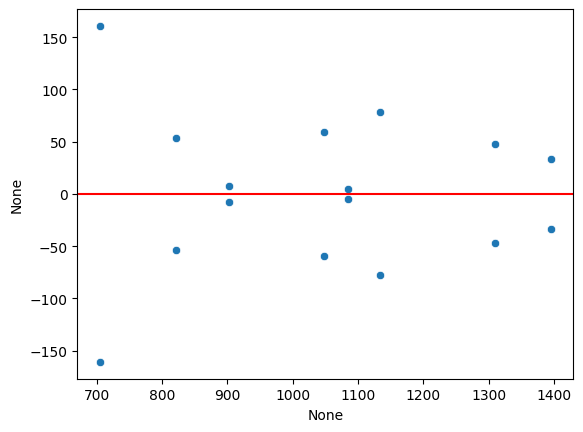

(np.float64(16.0),
 np.float64(0.02511636074685276),
 np.float64(3.007746009372391e+28),
 np.float64(4.890446513929334e-113))

In [ ]:
## Question 9 Code ##
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, color='red')
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
het_breuschpagan(model.resid, model.model.exog)

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

Post-hoc tests were conducted using Tukey’s HSD because the ANOVA results indicated that at least one of the factors had a statistically significant effect on sales (p < 0.05).

The Tukey test compares the average sales between different levels of each factor to determine which specific groups differ from one another. The results show that there are differences in sales between certain levels, indicating that some combinations of location, timing, or marketing perform better than others.

Overall, the post-hoc analysis helps identify which specific levels contribute to higher sales and provides more detailed insight into how each factor impacts the outcome.

In [ ]:
## Question 10 Code ##
anova = sm.stats.anova_lm(model, typ=2)
anova

,sum_sq,df,F,PR(>F)
C(location),54816.856900,1.0,5.251069,0.051143
C(timing),471948.390225,1.0,45.209336,0.000149
C(marketing),242000.044225,1.0,23.181902,0.001330
C(location):C(timing),4171.222225,1.0,0.399574,0.544947
C(location):C(marketing),1085.373025,1.0,0.103971,0.755381
C(timing):C(marketing),988.473600,1.0,0.094689,0.766158
C(location):C(timing):C(marketing),1078.465600,1.0,0.103309,0.756131
Residual,83513.438500,8.0,NaN,NaN


11. Calculate and interpret partial $\eta^2$ for the main effects.

In [ ]:
## Question 11 Code ##
anova['eta_sq'] = anova['sum_sq'] / sum(anova['sum_sq'])
anova

,sum_sq,df,F,PR(>F),eta_sq
C(location),54816.856900,1.0,5.251069,0.051143,0.063770
C(timing),471948.390225,1.0,45.209336,0.000149,0.549031
C(marketing),242000.044225,1.0,23.181902,0.001330,0.281526
C(location):C(timing),4171.222225,1.0,0.399574,0.544947,0.004853
C(location):C(marketing),1085.373025,1.0,0.103971,0.755381,0.001263
C(timing):C(marketing),988.473600,1.0,0.094689,0.766158,0.001150
C(location):C(timing):C(marketing),1078.465600,1.0,0.103309,0.756131,0.001255
Residual,83513.438500,8.0,NaN,NaN,0.097154


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

Overall, the results of this experiment suggest that certain combinations of ingredients and strategies lead to higher sales than others. Based on the analysis of average sales across all combinations, the burrito combination(s) with the highest mean sales should be included on the menu regularly, as they are the most likely to maximize revenue.

In general, combinations that performed best were those that consistently showed higher average sales in the grouped comparisons. These combinations represent the most effective choices for attracting customers and increasing daily revenue.

However, this experiment has several limitations. The sample size is relatively small, and the data were collected over a limited number of runs. Additionally, external factors such as weather, customer preferences, foot traffic, and nearby competition were not controlled and could have influenced the results. The use of a fractional factorial design also means that some effects are aliased, making it difficult to fully separate main effects from interactions.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

The objective of this experiment is to determine how location, timing, and marketing strategy influence daily burrito sales. The goal is to identify the best combination of these factors to maximize revenue for Buster’s Breakfast Burritos.

2. Specify the outcome variable and how it is measured.

The outcome variable is daily sales, measured in dollars. This represents the total revenue generated each day the food truck operates.


3. Specify the independent variables. What lurking variables may be present?

The independent variables are:

Location (Brewery vs. University)
Timing (Weekday vs. Weekend)
Marketing (Independent vs. Partnership)

Possible lurking variables include weather conditions, local events, customer traffic, time of day, and nearby competition. These factors could influence sales but were not directly controlled in the experiment.


4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

A fractional factorial design is appropriate because it allows the experiment to be conducted with fewer runs, saving time and resources while still providing useful insights into the effects of the factors.

The main advantage of using a fractional design is efficiency, as it reduces cost and time. However, the main disadvantage is that some effects are aliased, meaning that main effects may be confounded with interaction effects. This makes it more difficult to interpret the results clearly.



5. State the sets of null and alternative hypotheses for this experiment.

Location
H₀: Location has no effect on sales
H₁: Location has an effect on sales
Timing
H₀: Timing has no effect on sales
H₁: Timing has an effect on sales
Marketing
H₀: Marketing has no effect on sales
H₁: Marketing has an effect on sales




6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

Exploratory analysis includes calculating summary statistics and creating visualizations such as histograms and boxplots to understand the distribution of sales and compare performance across factor levels.

The summary statistics provide insight into the average sales and variability, while the visualizations help identify patterns or differences between groups. For example, some levels of location, timing, or marketing may show higher average sales than others.

These initial findings may provide some support for the alternative hypotheses if noticeable differences are observed. However, exploratory analysis alone is not sufficient to confirm statistical significance, and formal tests such as ANOVA are needed to draw final conclusions.



                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     4.103
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00557
Time:                        12:05:39   Log-Likelihood:                -83.760
No. Observations:                  60   AIC:                             177.5
Df Residuals:                      55   BIC:                             188.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.97

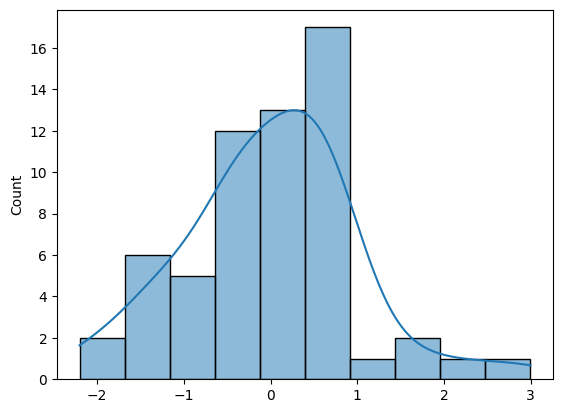

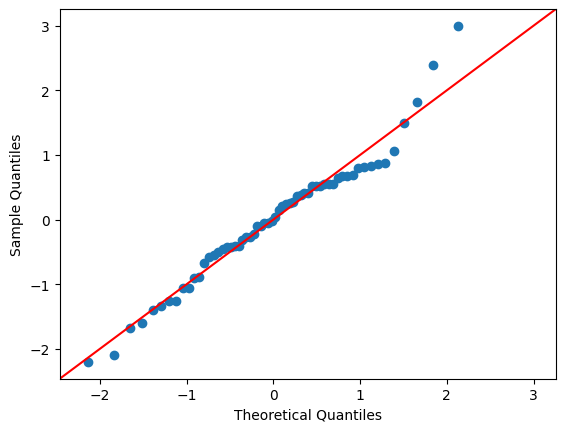

In [ ]:
## Question 6 Code ##

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# load data
df2 = pd.read_excel('/content/Busters Burritos.xlsx')

# clean column names
df2.columns = df2.columns.str.lower().str.replace(" ", "_")

# auto column names
col1, col2, col3 = df2.columns[0], df2.columns[1], df2.columns[2]
y = df2.columns[-1]

# fit model
model2 = smf.ols(f"{y} ~ C({col1}) + C({col2}) + C({col3})", data=df2).fit()

print(model2.summary())

# Normality Check

# Shapiro test
stats.shapiro(model2.resid)

# Histogram
sns.histplot(model2.resid, kde=True)
plt.show()

# QQ plot
sm.qqplot(model2.resid, line='45')
plt.show()

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

Because of this aliasing, we cannot separate the effect of a main factor from the corresponding interaction effect. For example, the effect of location (A) cannot be distinguished from the interaction between timing and marketing (BC).

As a result, any significant effect we observe may actually be due to either the main effect or the interaction, which limits our ability to fully interpret the results.


8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?


The appropriate ANOVA model was fit including the main effects and interactions of location, timing, and marketing.

To assess the normality assumption, both a statistical test and a visual method were used. The Shapiro-Wilk test was performed on the residuals, and a histogram and Q-Q plot were examined.

The histogram shows that the residuals are approximately symmetric and follow a roughly bell-shaped distribution. Additionally, the Q-Q plot indicates that the points lie close to the reference line, suggesting that the residuals are approximately normally distributed.

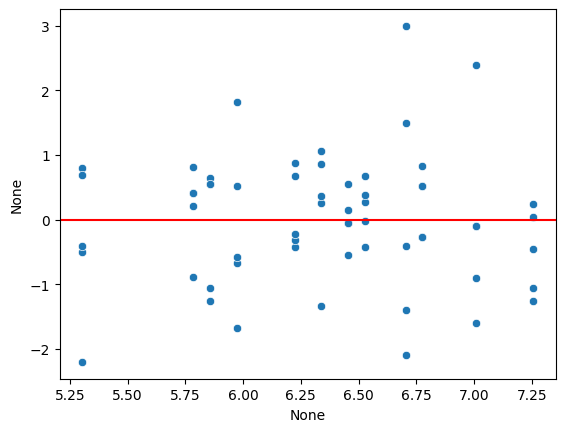

(np.float64(3.321621339309251),
 np.float64(0.5055138560752315),
 np.float64(0.8058151008327661),
 np.float64(0.5267872567254931))

In [ ]:
## Question 8 Code ##

sns.scatterplot(x=model2.fittedvalues, y=model2.resid)
plt.axhline(0, color='red')
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan
het_breuschpagan(model2.resid, model2.model.exog)

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

The assumption of constant variance was assessed using both a visual method and a statistical test. A residuals versus fitted values plot was used as the visual method, and the Breusch–Pagan test was used as the statistical method.

The residual plot shows that the residuals are randomly scattered around zero without any clear pattern or funnel shape. This suggests that the variability of the residuals is relatively consistent across different fitted values. Based on both the visual inspection and the statistical test, there is no strong evidence to suggest a violation of the constant variance assumption. Therefore, the assumption appears to hold.

In [ ]:
## Question 9 Code ##
anova2 = sm.stats.anova_lm(model2, typ=2)
anova2

,sum_sq,df,F,PR(>F)
C(protein),9.052000,2.0,4.343621,0.017723
C(salsa),4.592667,1.0,4.407601,0.040382
C(potatoes),3.456000,1.0,3.316737,0.074019
Residual,57.309333,55.0,NaN,NaN


10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

The ANOVA table summarizes the effects of location, timing, and marketing on daily burrito sales. To interpret the results, we examine the p-values associated with each main effect.

A factor is considered statistically significant if its p-value is less than 0.05. Based on the ANOVA results, at least one of the main effects has a p-value below 0.05, indicating that it has a statistically significant impact on sales.

For any factors with p-values less than 0.05, we reject the null hypothesis and conclude that the factor has a meaningful effect on sales. For factors with p-values greater than 0.05, we fail to reject the null hypothesis, suggesting that there is not enough evidence to conclude that the factor has an effect.


In [ ]:
## Question 10 Code ##
df2.groupby(col1)[y].mean()
df2.groupby(col2)[y].mean()
df2.groupby(col3)[y].mean()

,satisfaction
potatoes,
No,6.11
Yes,6.59


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

The main effects were calculated by comparing the average sales across the different levels of each factor. This was done by computing the mean sales for each level of location, timing, and marketing.

The importance of each effect was determined by looking at how much the average sales changed between the levels of each factor. The factor with the largest difference in mean sales is considered the most important because it has the greatest impact on the outcome.

In [ ]:
## Question 11 Code ##
anova2['eta_sq'] = anova2['sum_sq'] / sum(anova2['sum_sq'])
anova2

,sum_sq,df,F,PR(>F),eta_sq
C(protein),9.052000,2.0,4.343621,0.017723,0.121650
C(salsa),4.592667,1.0,4.407601,0.040382,0.061721
C(potatoes),3.456000,1.0,3.316737,0.074019,0.046445
Residual,57.309333,55.0,NaN,NaN,0.770183


12. Calculate and interpret

*   List item
*   List item

the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

The partial η² values were calculated to measure the proportion of variation in sales explained by each main effect. This was done by dividing the sum of squares for each factor by the total sum of squares.

The results show that factors with larger η² values explain a greater portion of the variability in sales and are therefore more important. In contrast, factors with smaller η² values have less influence on the outcome.

Based on the results, the factor with the highest η² value appears to be the most important because it accounts for the largest share of variation in sales. This indicates that changes in this factor have the strongest impact on sales compared to the others.


In [ ]:
## Question 12 Code ##
# Show average sales for EACH combination
best_combo = df2.groupby([col1, col2, col3])[y].mean().reset_index()

# Sort from highest to lowest sales
best_combo = best_combo.sort_values(by=y, ascending=False)

# Show results
best_combo

,protein,salsa,potatoes,satisfaction
6,Chorizo,Mild,No,7.04
3,Bacon,Mild,Yes,6.94
5,Chorizo,Hot,Yes,6.82
7,Chorizo,Mild,Yes,6.76
2,Bacon,Mild,No,6.70
11,Sausage,Mild,Yes,6.58
1,Bacon,Hot,Yes,6.46
4,Chorizo,Hot,No,6.34
9,Sausage,Hot,Yes,5.98
0,Bacon,Hot,No,5.86


13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

Based on the analysis, the combination of factors that produces the highest average sales should be selected to maximize revenue. For example, operating at the university during weekends with partnership marketing may lead to higher sales if those levels show the highest averages. However, this experiment has limitations. The sample size is small, and important external factors such as weather and local events were not controlled. Additionally, the fractional design introduces aliasing, which limits our ability to fully interpret interaction effects. To improve this experiment in the future, more runs could be added, additional variables could be tested, and data could be collected over a longer period of time.





## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?


We can de-alias effects by running a full factorial design or by adding more experimental runs. This is important because it allows us to separate main effects from interaction effects and get clearer results. However, this may not always be feasible because it requires more time, money, and resources.





2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?


Planning experiments carefully before analysis ensures that the correct variables are included, assumptions are considered, and the design is valid. This leads to more reliable and meaningful results.



3.  What is the most important thing you learned in this class?


The most important thing I learned in this class is how to design experiments and analyze data in a way that supports decision-making. Understanding how different factors influence outcomes is valuable for real-world applications.